In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# ── Config ────────────────────────────────────────────────────────────────────
security1 = "BBB"   # independent variable (x in regression)
security2 = "DDD"   # dependent variable  (y in regression, the one being traded)

# IND is always the risk-free rate for the Sharpe ratio — hardcoded below

In [10]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [11]:
test_data=hist_df[hist_df["day"]>30]
test_data

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
11730,0,31,0,120.04,245.33,332.03,267.17,178.59,255.78
11731,1,31,1,120.04,245.28,331.77,267.21,178.84,255.78
11732,2,31,2,120.08,246.00,332.03,266.66,178.69,255.85
11733,3,31,3,120.18,246.40,333.47,266.38,179.38,256.40
11734,4,31,4,120.29,247.08,334.54,267.58,179.36,257.14
...,...,...,...,...,...,...,...,...,...
23455,386,60,386,121.71,261.64,362.42,208.12,193.39,256.39
23456,387,60,387,121.63,261.68,362.00,208.87,192.79,256.33
23457,388,60,388,121.78,262.01,362.27,209.52,193.42,256.81
23458,389,60,389,121.65,261.07,362.55,209.51,193.33,256.62


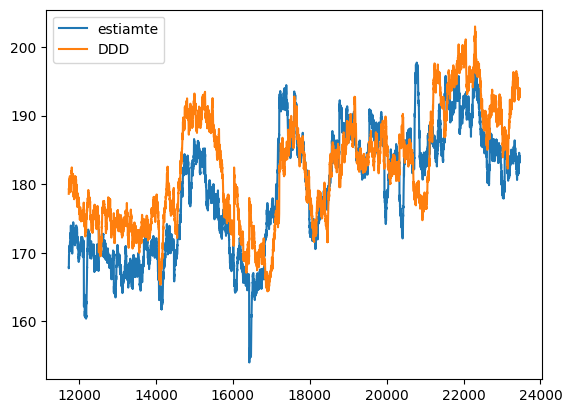

In [12]:
intercept,coef=-0.878753,0.508236
sd=5.792330

y_fit=test_data[security1]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(test_data[security2],label=security2)
#plt.plot(test_data[security1],label=[security1])

plt.legend()

In [13]:
test_data.index

RangeIndex(start=11730, stop=23460, step=1)

In [14]:
diff=test_data[security2]-y_fit

start_capital=1000000
total=start_capital
per=total/2
tot_ETF=0
tot_IND=0

buy_in=1.2222222222222223
back=0.1

profit=[1]

for i in test_data.index:
    if(i==11730): continue

    if(diff[i]>=buy_in*sd and diff[i-1]<buy_in*sd):
        amount_etf=per//test_data[security2][i]
        amount_ind=per//test_data[security1][i]

        tot_IND+=amount_ind
        tot_ETF-=amount_etf

        total+=amount_etf*test_data[security2][i]
        total-=amount_ind*test_data[security1][i]

        #print(tot_ETF,i,total)

    if(diff[i]<=back*sd and diff[i-1]>back*sd and tot_ETF<0):
        total-=tot_ETF*test_data[security2][i]
        total+=tot_IND*test_data[security1][i]
        tot_ETF=0
        tot_IND=0

        #print(tot_ETF,i,total)


    profit.append(total/start_capital)

profit=pd.DataFrame(np.array(profit))
#print(total)

Rp=total/start_capital
Rf=(test_data["IND"][23459]/test_data["IND"][11730])
#test_data["IND"]
sigma=np.sqrt(profit[0].var())

sharpe=(Rp-Rf)/sigma

print(sharpe)

3.4974895138753617
